# MNIST MLP3 — AdamW baseline

This is the clean AdamW control: 55,000 optimization examples, a fixed 5,000-example validation split, and the official test set used only for monitoring. AdamW uses step-level warm-up/cosine decay from 1e-3 to 1e-5, betas (0.90, 0.999), matrix-only weight decay 1e-2, and gradient clipping at 1.0.

Results are written beneath the versioned suite directory `mnist_mlp3_recipe_v3`. Legacy unversioned result directories are ignored, so an old 20-epoch constant-LR run cannot be resumed or compared accidentally.

At epoch zero and every epoch the code runs `watcher.analyze(ERG=True, randomize=True)` and retains direct `alpha`, `ERG_gap`, and `num_traps`. The standard plot bundle includes `7_layerwise_weightwatcher_num_traps_95ci.png`.


In [1]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

ROOT = None
for path in [Path.cwd(), *Path.cwd().parents]:
    candidate = path / 'baseline'
    if (candidate / 'rg_baselines').is_dir():
        ROOT = candidate
        break
    if (path / 'rg_baselines').is_dir():
        ROOT = path
        break
if ROOT is None:
    raise RuntimeError('Run from a current clone of CalculatedContent/rg_optimizers.')
ROOT = ROOT.resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from rg_baselines import (
    BaselineConfig,
    DEFAULT_BASELINE_SEEDS,
    MNIST_REFERENCE_RECIPE_VERSION,
    MNIST_REFERENCE_SUITE_SLUG,
    plot_all_replicates,
    run_baseline_replicates,
)

BASE_RUN_ROOT = Path(
    os.environ.get('RG_BASELINE_RUN_ROOT', ROOT / 'runs')
).expanduser().resolve()
RUN_ROOT = BASE_RUN_ROOT / MNIST_REFERENCE_SUITE_SLUG
DATA_DIR = Path(
    os.environ.get('RG_BASELINE_DATA_DIR', ROOT / 'data')
).expanduser().resolve()
for directory in (BASE_RUN_ROOT, RUN_ROOT, DATA_DIR):
    directory.mkdir(parents=True, exist_ok=True)


In [2]:
CONFIG = BaselineConfig(
    optimizer='adamw',
    epochs=30,
    validation_size=5_000,
    adamw_learning_rate=1e-3,
    adamw_min_learning_rate=1e-5,
    adamw_warmup_epochs=1,
    adamw_beta1=0.90,
    adamw_beta2=0.999,
    adamw_weight_decay=1e-2,
    ww_randomize=True,
    save_epoch_checkpoints=True,
)
CONFIG.validate()
if CONFIG.recipe_version != MNIST_REFERENCE_RECIPE_VERSION:
    raise RuntimeError(
        f'Notebook expects MNIST recipe v{MNIST_REFERENCE_RECIPE_VERSION}; '
        f'loaded v{CONFIG.recipe_version}. Pull current main before running.'
    )

SEEDS = DEFAULT_BASELINE_SEEDS
assert len(SEEDS) == 3 and len(set(SEEDS)) == 3
RUN_DIR = RUN_ROOT / CONFIG.run_slug
PLOT_DIR = RUN_DIR / 'plots'
for directory in (RUN_DIR, PLOT_DIR):
    directory.mkdir(parents=True, exist_ok=True)

LEGACY_DIR = BASE_RUN_ROOT / CONFIG.run_slug
if LEGACY_DIR.is_dir() and LEGACY_DIR != RUN_DIR:
    print('Ignoring legacy unversioned artifacts:', LEGACY_DIR)
print('MNIST reference recipe:', CONFIG.recipe_version)
print('versioned suite root:', RUN_ROOT)
print('current run directory:', RUN_DIR)
display(pd.DataFrame([CONFIG.__dict__]))


MNIST reference recipe: 3
versioned suite root: /private/tmp/rg_optimizers/baseline/notebooks/runs/mnist_mlp3_recipe_v3
current run directory: /private/tmp/rg_optimizers/baseline/notebooks/runs/mnist_mlp3_recipe_v3/adamw


,optimizer,recipe_version,initialization,seed,epochs,batch_size,validation_size,split_seed,num_workers,grad_clip_norm,...,muon_aux_beta1,muon_aux_beta2,muon_aux_eps,muon_aux_weight_decay,ww_min_evals,ww_max_evals,ww_svd_method,ww_randomize,save_epoch_checkpoints,strict_metrics
0,adamw,3,kaiming_uniform_relu_hidden_xavier_uniform_hea...,1337,30,128,5000,20260807,0,1.0,...,0.9,0.95,1.000000e-08,0.01,8,None,accurate,True,True,True


## Run or resume three complete trajectories

Latest, validation-selected, final, and per-epoch checkpoints are persisted. Only checkpoints carrying the current recipe fingerprint inside the versioned suite directory can resume.



=== AdamW: replicate 1/3, seed=1337 ===


PyTorch is available but CUDA is not. Defaulting to NumPy for SVD


Import error , reetting to svd accurate methods


Running on macOS.
Running on macOS.


SMALL N PL FIT


...

epoch=028 | AdamW | lr=2.157e-05 | train=1.0000 | val=0.9866 | test=0.9846


SMALL N PL FIT


epoch=029 | AdamW | lr=1.290e-05 | train=1.0000 | val=0.9866 | test=0.9846


SMALL N PL FIT


epoch=030 | AdamW | lr=1.000e-05 | train=1.0000 | val=0.9866 | test=0.9847


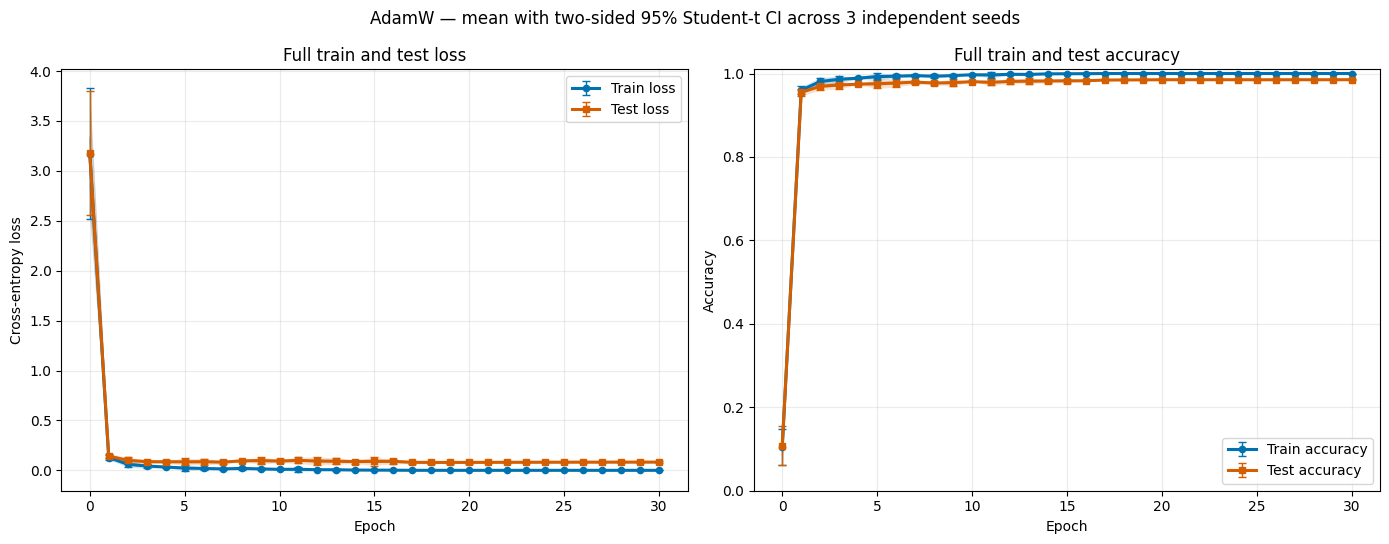

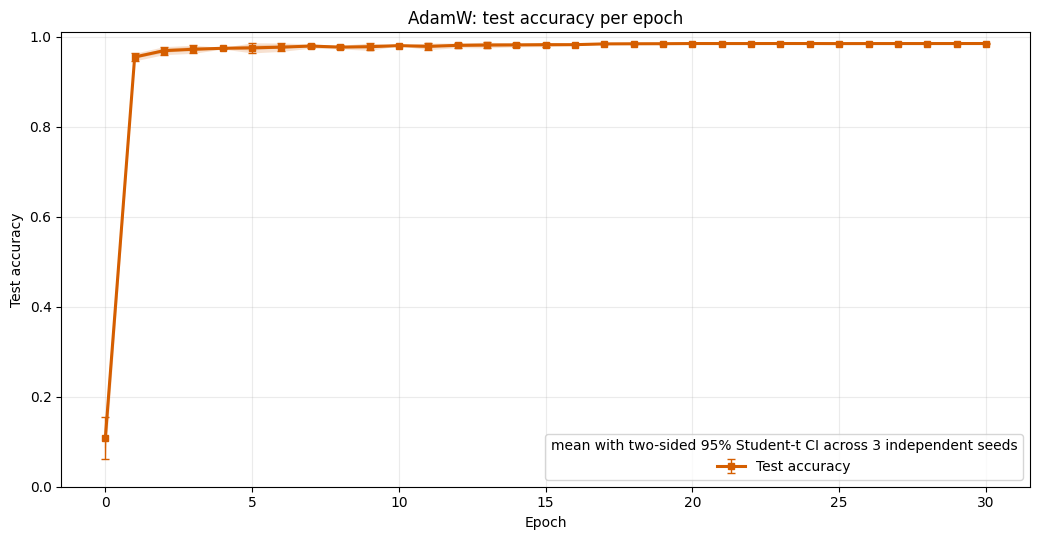

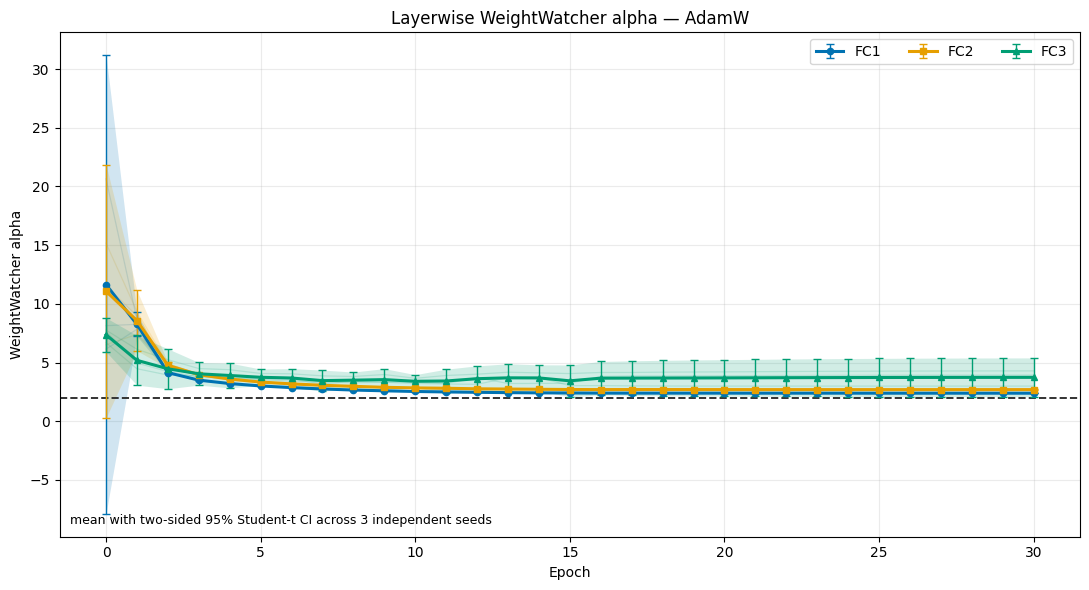

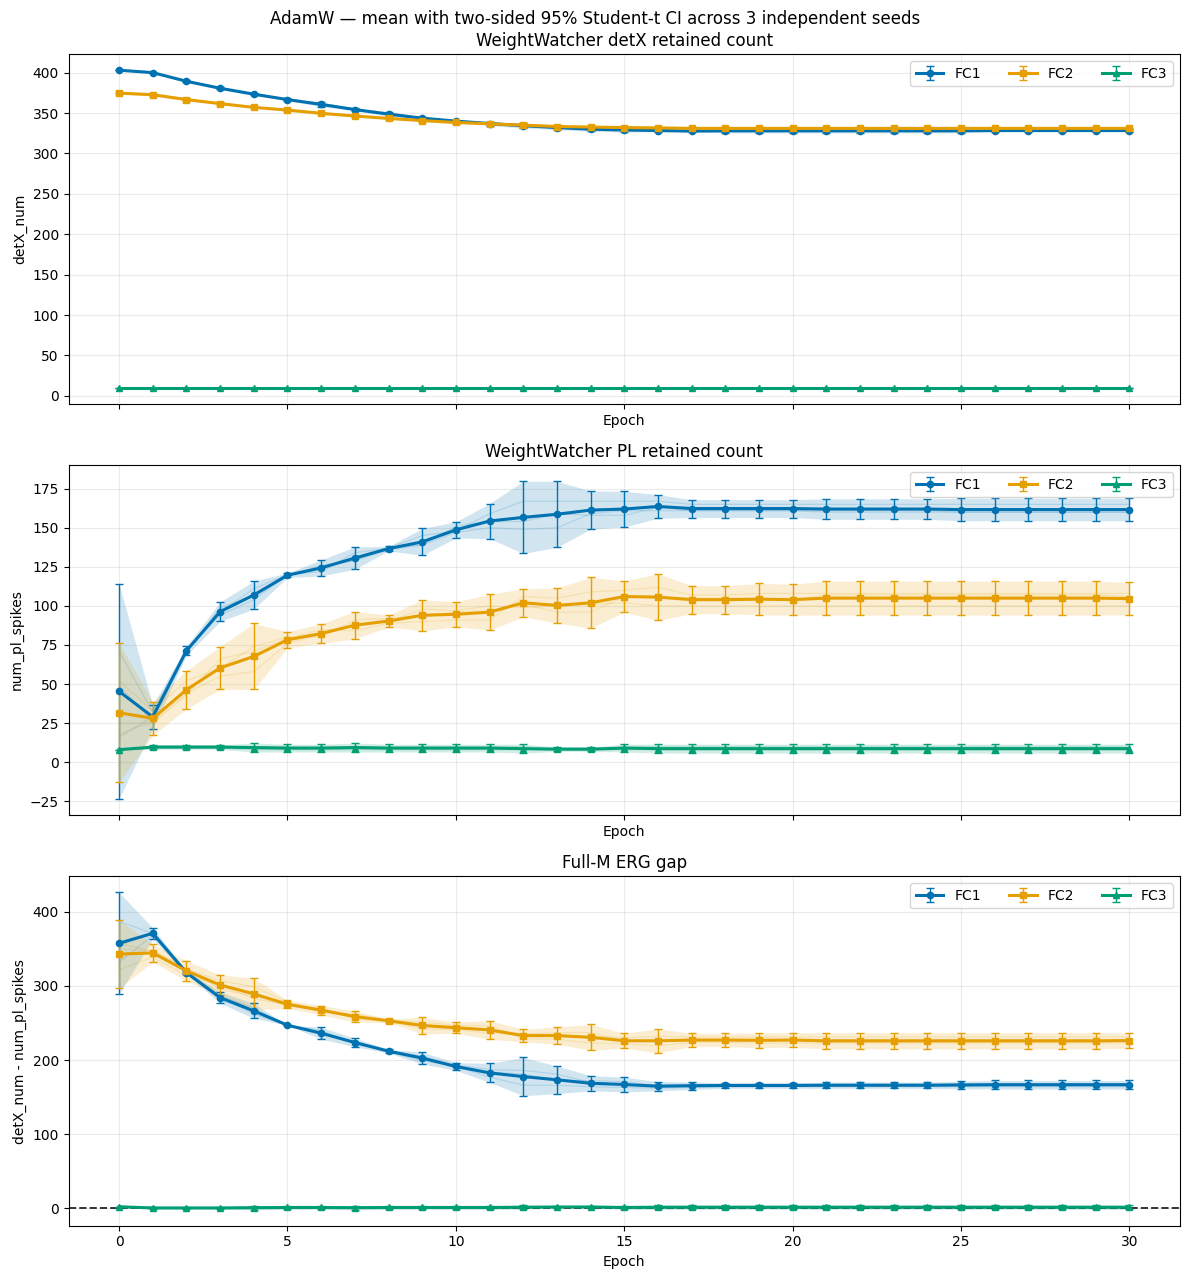

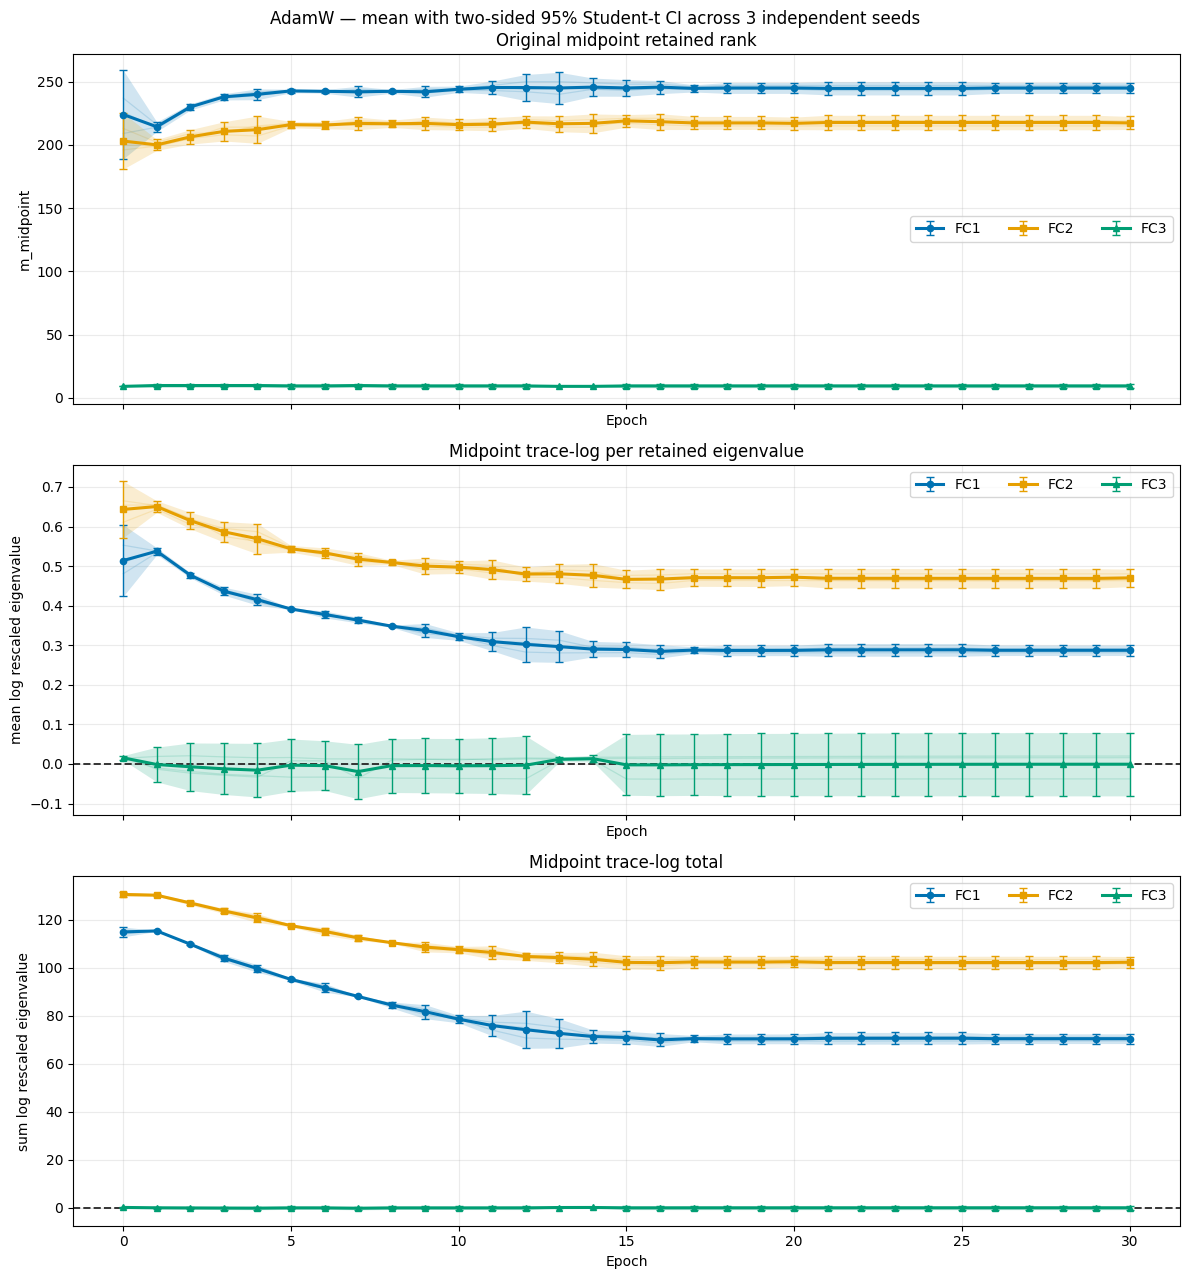

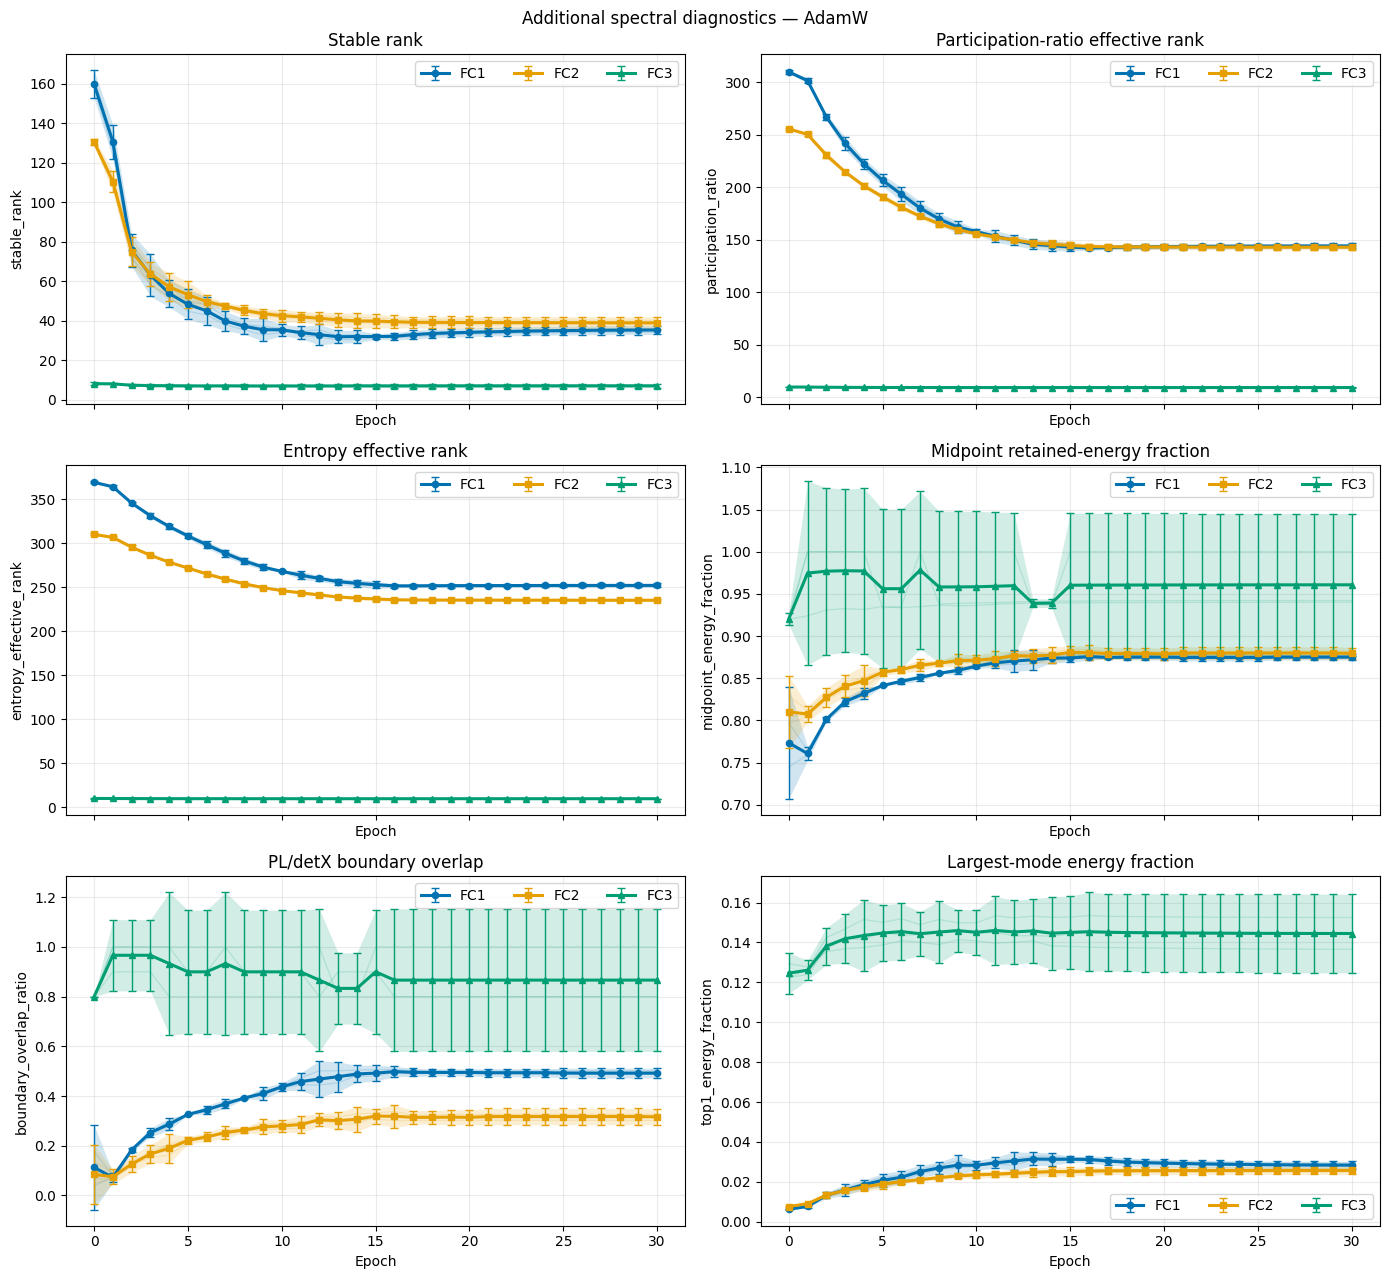

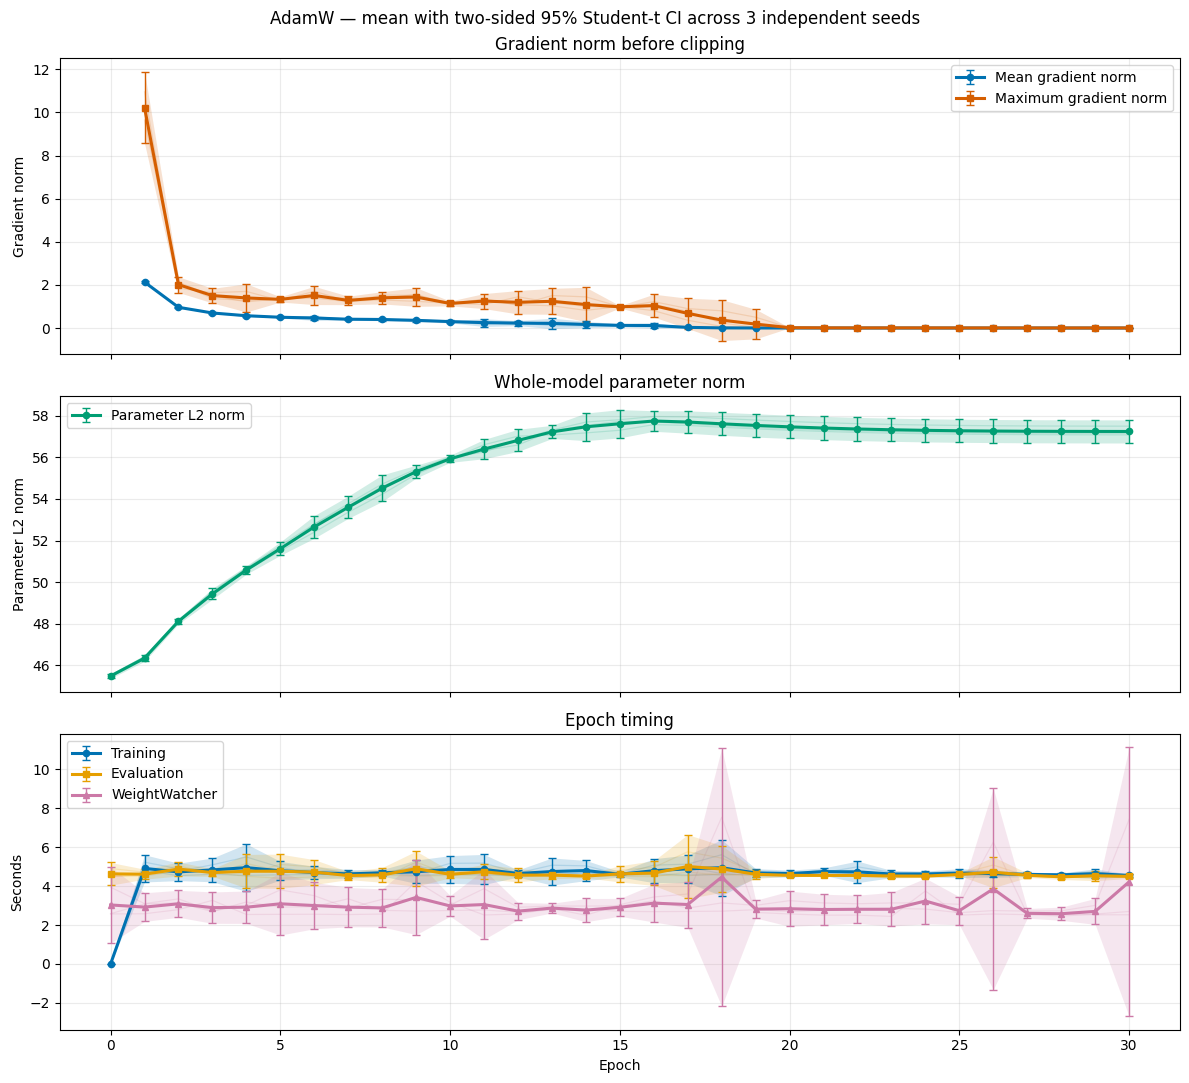

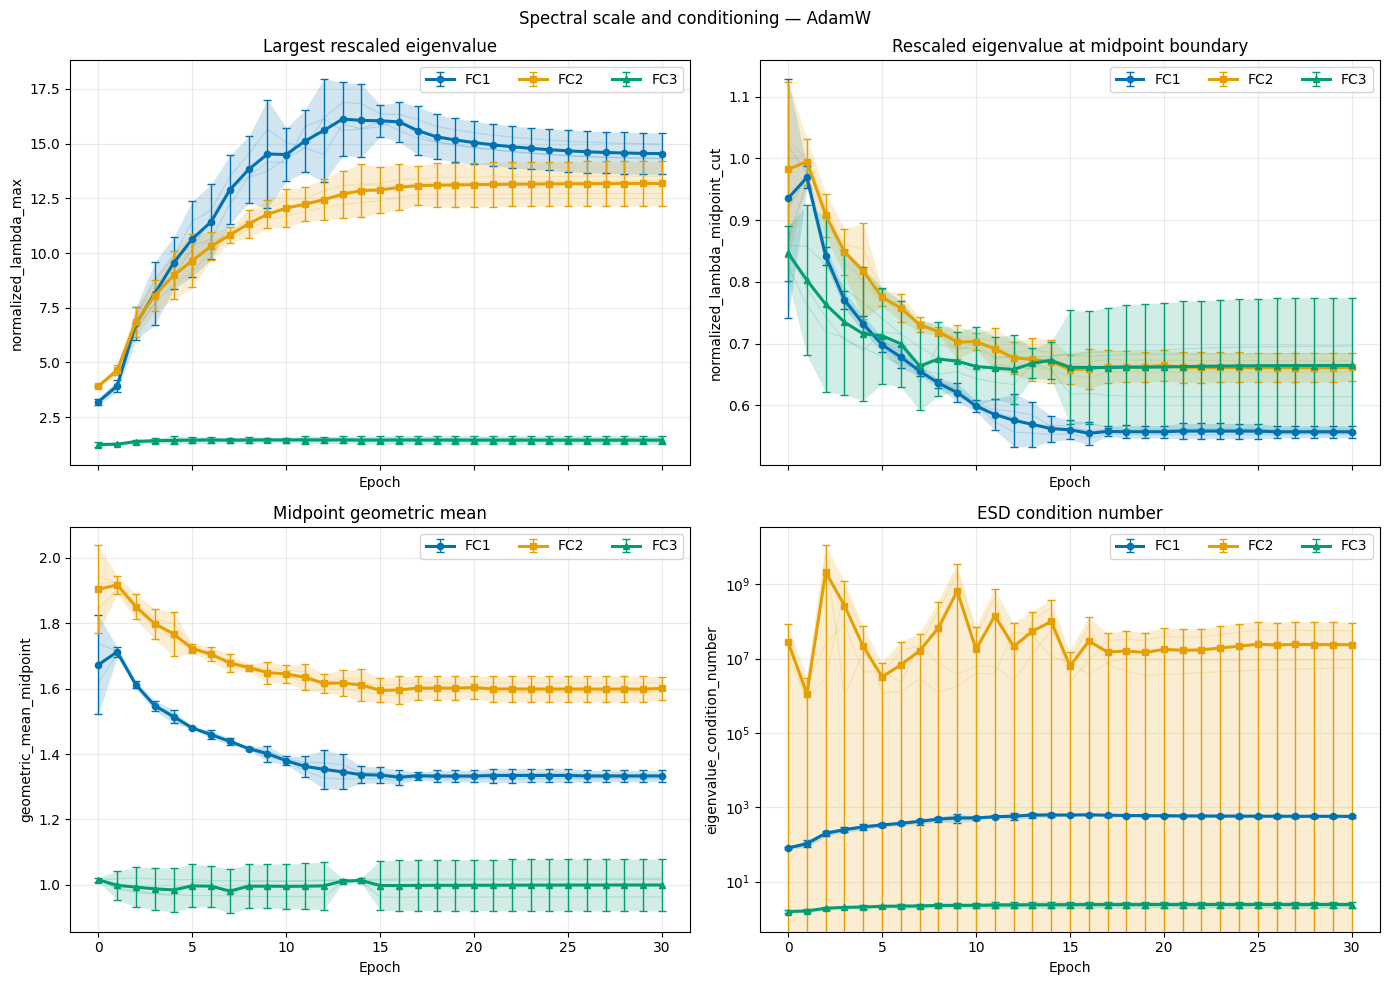

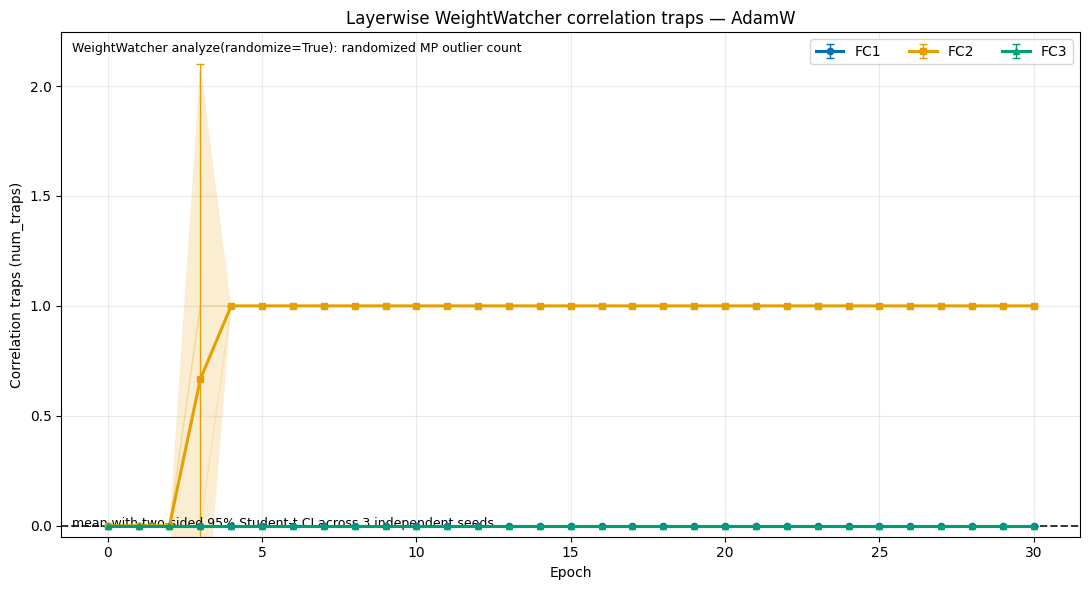

[<Figure size 1400x550 with 2 Axes>,
 <Figure size 1050x550 with 1 Axes>,
 <Figure size 1100x600 with 1 Axes>,
 <Figure size 1200x1300 with 3 Axes>,
 <Figure size 1200x1300 with 3 Axes>,
 <Figure size 1400x1300 with 6 Axes>,
 <Figure size 1200x1100 with 3 Axes>,
 <Figure size 1400x1000 with 4 Axes>,
 <Figure size 1100x600 with 1 Axes>]

In [3]:
suite = run_baseline_replicates(
    CONFIG,
    seeds=SEEDS,
    data_dir=DATA_DIR,
    output_dir=RUN_DIR,
    progress=True,
    confidence=0.95,
    resume=True,
    overwrite=False,
)
assert suite.config_template.recipe_version == MNIST_REFERENCE_RECIPE_VERSION
plot_all_replicates(suite, output_dir=PLOT_DIR, show=True)


## Train, validation, test, and learning-rate trajectories

All bands are two-sided 95% Student-t intervals across complete runs. Validation loss is the only checkpoint-selection signal.


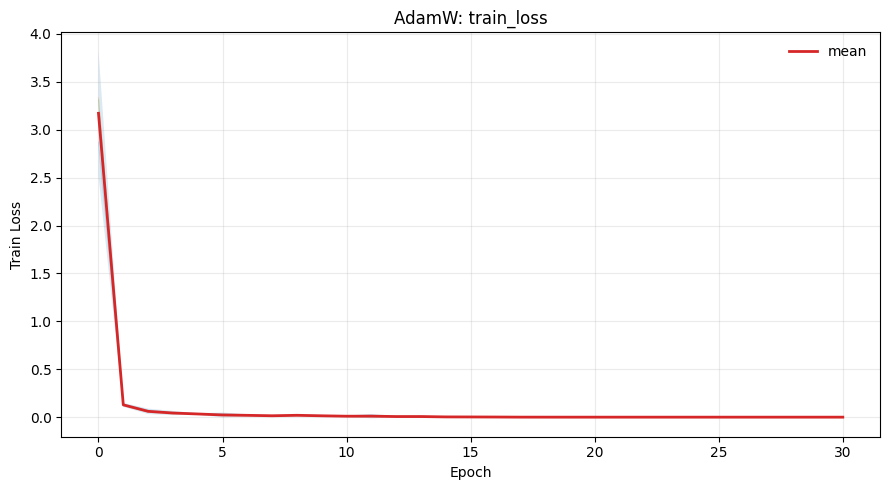

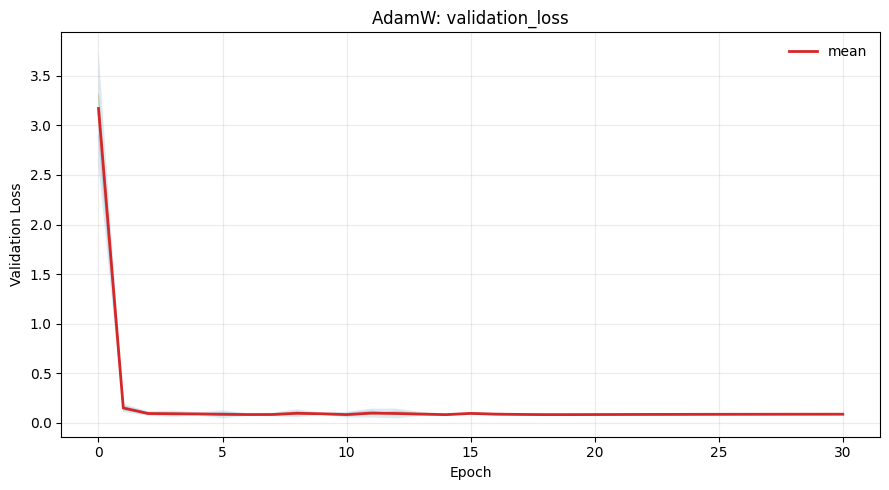

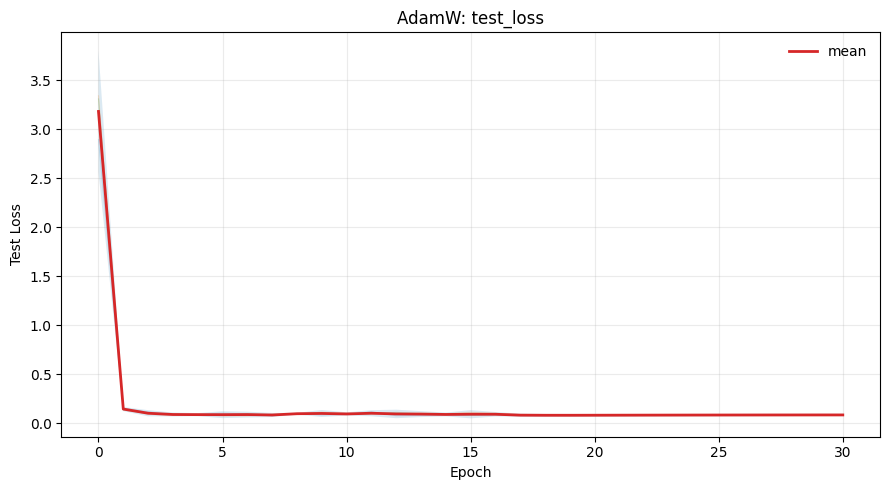

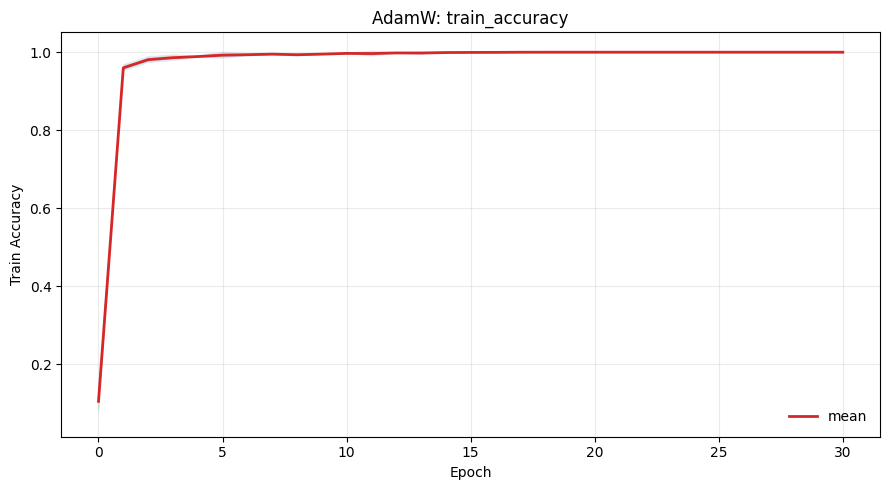

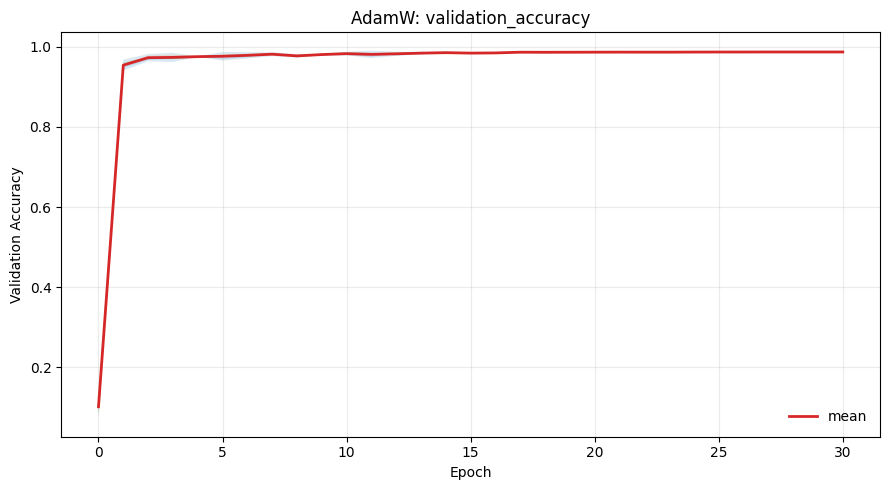

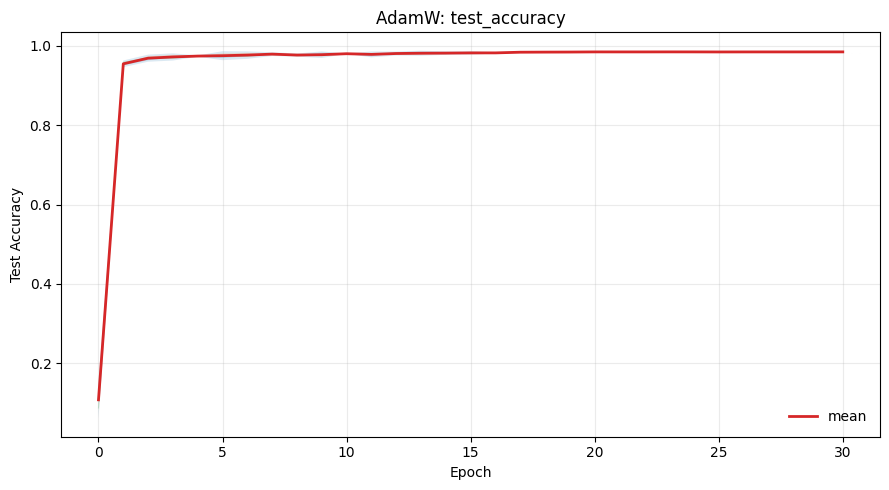

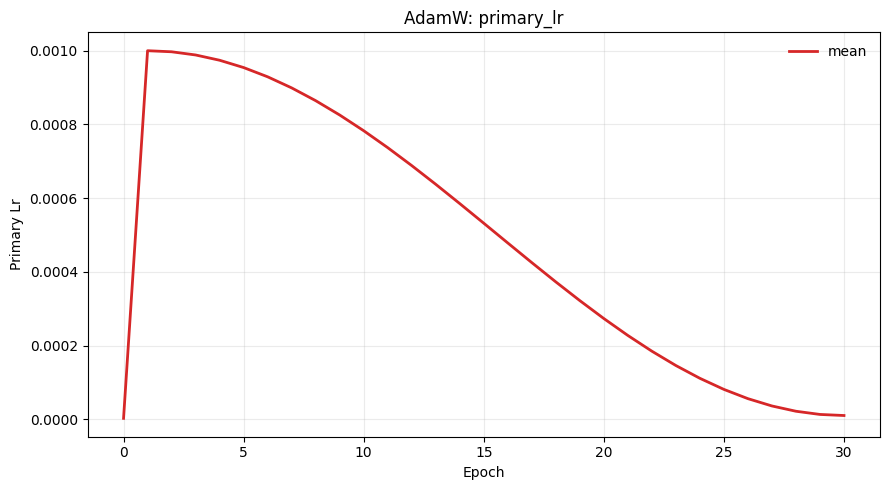

,run,optimizer,optimizer_label,epoch,metric,n,mean,std,sem,confidence,critical_value,ci_half_width,ci_low,ci_high,minimum,maximum
6,AdamW,adamw,AdamW,0,primary_lr,3,0.000002,0.000000,0.000000,0.95,4.302653,0.000000,0.000002,0.000002,0.000002,0.000002
22,AdamW,adamw,AdamW,1,primary_lr,3,0.001000,0.000000,0.000000,0.95,4.302653,0.000000,0.001000,0.001000,0.001000,0.001000
43,AdamW,adamw,AdamW,2,primary_lr,3,0.000997,0.000000,0.000000,0.95,4.302653,0.000000,0.000997,0.000997,0.000997,0.000997
64,AdamW,adamw,AdamW,3,primary_lr,3,0.000988,0.000000,0.000000,0.95,4.302653,0.000000,0.000988,0.000988,0.000988,0.000988
85,AdamW,adamw,AdamW,4,primary_lr,3,0.000974,0.000000,0.000000,0.95,4.302653,0.000000,0.000974,0.000974,0.000974,0.000974
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
542,AdamW,adamw,AdamW,26,validation_loss,3,0.087839,0.004529,0.002615,0.95,4.302653,0.011251,0.076587,0.099090,0.083963,0.092818
563,AdamW,adamw,AdamW,27,validation_loss,3,0.088096,0.004506,0.002602,0.95,4.302653,0.011194,0.076901,0.099290,0.084239,0.093049
584,AdamW,adamw,AdamW,28,validation_loss,3,0.088275,0.004468,0.002579,0.95,4.302653,0.011098,0.077177,0.099373,0.084451,0.093185
605,AdamW,adamw,AdamW,29,validation_loss,3,0.088407,0.004444,0.002566,0.95,4.302653,0.011039,0.077369,0.099446,0.084615,0.093297


In [4]:
for metric in [
    'train_loss', 'validation_loss', 'test_loss',
    'train_accuracy', 'validation_accuracy', 'test_accuracy',
    'primary_lr',
]:
    summary = suite.performance_summary[
        suite.performance_summary['metric'].eq(metric)
    ].sort_values('epoch')
    figure, axis = plt.subplots(figsize=(9, 5))
    for seed, run in suite.performance.groupby('seed'):
        axis.plot(run['epoch'], run[metric], alpha=0.18, linewidth=0.8)
    axis.plot(summary['epoch'], summary['mean'], linewidth=2.0, label='mean')
    axis.fill_between(
        summary['epoch'], summary['ci_low'], summary['ci_high'], alpha=0.16
    )
    axis.set(
        xlabel='Epoch',
        ylabel=metric.replace('_', ' ').title(),
        title=f'{CONFIG.optimizer_label}: {metric}',
    )
    axis.grid(alpha=0.25)
    axis.legend(frameon=False)
    figure.tight_layout()
    figure.savefig(
        PLOT_DIR / f'{metric}_95ci.png', dpi=170, bbox_inches='tight'
    )
    plt.show()

display(
    suite.performance_summary[
        suite.performance_summary['metric'].isin([
            'train_loss', 'validation_loss', 'test_loss',
            'train_accuracy', 'validation_accuracy', 'test_accuracy',
            'primary_lr',
        ])
    ].sort_values(['metric', 'epoch'])
)


## Layerwise WeightWatcher diagnostics


In [5]:
required = [
    'alpha', 'ERG_gap', 'num_traps',
    'm_midpoint', 'trace_log_midpoint_per_eval',
]
rows = suite.spectral_summary[
    suite.spectral_summary['metric'].isin(required)
].sort_values(['metric', 'layer', 'epoch'])
assert rows['n'].eq(3).all()
display(rows)


,run,optimizer,optimizer_label,layer,epoch,metric,n,mean,std,sem,confidence,critical_value,ci_half_width,ci_low,ci_high,minimum,maximum
4,AdamW,adamw,AdamW,fc1,0,ERG_gap,3,357.666667,27.682726,15.982629,0.95,4.302653,68.767704,288.898962,426.434371,332.000000,387.000000
33,AdamW,adamw,AdamW,fc1,1,ERG_gap,3,371.000000,3.000000,1.732051,0.95,4.302653,7.452413,363.547587,378.452413,368.000000,374.000000
62,AdamW,adamw,AdamW,fc1,2,ERG_gap,3,318.000000,1.000000,0.577350,0.95,4.302653,2.484138,315.515862,320.484138,317.000000,319.000000
91,AdamW,adamw,AdamW,fc1,3,ERG_gap,3,284.333333,3.055050,1.763834,0.95,4.302653,7.589166,276.744167,291.922499,281.000000,287.000000
120,AdamW,adamw,AdamW,fc1,4,ERG_gap,3,266.333333,4.041452,2.333333,0.95,4.302653,10.039523,256.293810,276.372856,262.000000,270.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2558,AdamW,adamw,AdamW,fc3,26,trace_log_midpoint_per_eval,3,-0.000743,0.032144,0.018558,0.95,4.302653,0.079849,-0.080592,0.079106,-0.037783,0.019832
2587,AdamW,adamw,AdamW,fc3,27,trace_log_midpoint_per_eval,3,-0.000695,0.032173,0.018575,0.95,4.302653,0.079922,-0.080617,0.079227,-0.037768,0.019910
2616,AdamW,adamw,AdamW,fc3,28,trace_log_midpoint_per_eval,3,-0.000658,0.032195,0.018588,0.95,4.302653,0.079977,-0.080635,0.079319,-0.037757,0.019965
2645,AdamW,adamw,AdamW,fc3,29,trace_log_midpoint_per_eval,3,-0.000634,0.032209,0.018596,0.95,4.302653,0.080012,-0.080645,0.079378,-0.037748,0.020002


In [6]:
required_paths = [
    RUN_DIR / 'performance_by_epoch_and_seed.csv',
    RUN_DIR / 'spectral_metrics_by_epoch_layer_and_seed.csv',
    RUN_DIR / 'performance_summary_95ci.csv',
    RUN_DIR / 'spectral_summary_95ci.csv',
    RUN_DIR / 'replicate_manifest.json',
    PLOT_DIR / '7_layerwise_weightwatcher_num_traps_95ci.png',
]
for seed in SEEDS:
    seed_dir = RUN_DIR / 'seeds' / f'seed_{seed}'
    required_paths.extend([
        seed_dir / 'checkpoint_latest.pt',
        seed_dir / 'checkpoint_best.pt',
        seed_dir / 'final_state.pt',
        seed_dir / 'test_results.json',
        seed_dir / 'run_complete.json',
    ])
missing = [path for path in required_paths if not path.is_file()]
if missing:
    raise RuntimeError(
        'Missing required artifacts:\n' + '\n'.join(map(str, missing))
    )
print('verified artifacts:', len(required_paths))


verified artifacts: 21
